# SIT215 Assignment 1 - Task HD Level
**Student ID:** s224326349  
**Name:** Angodavidanelage Rukshan Anthony Dias  

## Task 1: Problem Formation and Environment

We created a wheelchair-accessible navigation environment centered around [Vermont South, VIC 3133]. The environment includes over 30 annotated path segments representing realistic facilities and constraints.

**Tools Used:**
- Google My Maps (or OpenStreetMap) to identify and plan path segments.
- Python for graph representation and node plotting.

**Accessibility Features Included:**
- Kerb ramps, pedestrian crossings, accessible ATMs, restrooms, hospitals, and community services.

Each node was selected based on physical landmarks or practical assumptions from real-world layouts using Google Maps.


In [52]:
# If the packages are not installed, install the below packages with the below commands 
#!pip install pandas
#!pip install networkx
#!pip install matplotlib
#!pip install tabulate
#!pip install seaborn
#!pip install folium

In [53]:
import pandas as pd
import heapq
import math
import networkx as nx
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns
import folium

### Define Location Coordinates

The following dictionary stores latitude and longitude for each wheelchair-accessible location such as lifts, ramps, and entrances. These coordinates are used to calculate distances for the A* heuristic.


In [55]:
# Define wheelchair-accessible locations (nodes with coordinates)
locations = {
    "Library": (-37.8568, 145.1735),
    "Shopping Centre": (-37.8572, 145.1750),
    "Parking Space": (-37.8575, 145.1762),
    "Medical Centre": (-37.8580, 145.1755),
    "Park Entrance": (-37.8585, 145.1770),
    "Pathway": (-37.8579, 145.1743),
    "Bus Stop": (-37.8565, 145.1728),
    "Mall Entrance": (-37.8590, 145.1780),
    "Pharmacy": (-37.8577, 145.1768),
    "Pedestrian Ramp": (-37.8569, 145.1730),
    "Water Taps": (-37.8573, 145.1748),
    "Accessible ATM": (-37.8571, 145.1752),
    "Supermarket": (-37.8566, 145.1725),
    "Multi-level Parking": (-37.8574, 145.1742),
    "Hospital": (-37.8578, 145.1757),
    "Cinema": (-37.8582, 145.1765),
    "Restaurant": (-37.8584, 145.1778),
    "Public Restroom": (-37.8567, 145.1738),
    "School Entrance": (-37.8587, 145.1785),
    "Community Centre": (-37.8576, 145.1759),
    
#10 more parh segments for the D task
    
    "Post Office": (-37.8570, 145.1757),
    "Playground (Accessible)": (-37.8588, 145.1772),
    "Tactile Crossing": (-37.8564, 145.1741),
    "Kerb Ramp - Market Street": (-37.8579, 145.1737),
    "Bicycle Parking": (-37.8583, 145.1761),
    "Community Garden": (-37.8581, 145.1749),
    "Wheelchair Drop-off Point": (-37.8572, 145.1733),
    "Rehab Clinic Entrance": (-37.8586, 145.1756),
    "Indoor Pool Ramp": (-37.8592, 145.1769),
    "Childcare Access Path": (-37.8575, 145.1727),
    "Flexiata": (-37.8573, 145.1734),
    "Forest Hill Baseball Club": (-37.8582, 145.1736),
    "Billabong Park Playground": (-37.8580, 145.1730),
    "Birralee Preschool": (-37.8591, 145.1726),
    "Holy Saviour Parish": (-37.8600, 145.1757)
}

# Graph with edges and weights
graph = {
    "Library": {"Shopping Centre": 150, "Bus Stop": 200, "Pedestrian Ramp": 80, "Kerb Ramp - Market Street": 80, "Wheelchair Drop-off Point": 85},
    "Shopping Centre": {"Library": 150, "Parking Space": 130, "Medical Centre": 170, "Post Office": 70},
    "Parking Space": {"Shopping Centre": 130, "Medical Centre": 90, "Mall Entrance": 200},
    "Medical Centre": {"Shopping Centre": 170, "Parking Space": 90, "Park Entrance": 160, "Post Office": 85, "Community Garden": 70},
    "Park Entrance": {"Medical Centre": 160, "Mall Entrance": 180, "Playground (Accessible)": 60},
    "Pathway": {"Pedestrian Ramp": 100, "Bus Stop": 110, "Water Taps": 140, "Kerb Ramp - Market Street": 95},
    "Bus Stop": {"Library": 200, "Pedestrian Ramp": 120, "Supermarket": 150, "Tactile Crossing": 90, "Childcare Access Path": 95},
    "Mall Entrance": {"Parking Space": 200, "Park Entrance": 180, "School Entrance": 170, "Indoor Pool Ramp": 120},
    "Pharmacy": {"Parking Space": 120, "Community Centre": 140, "Bicycle Parking": 60},
    "Pedestrian Ramp": {"Library": 80, "Pathway": 100, "Bus Stop": 120},
    "Water Taps": {"Pathway": 140, "Multi-level Parking": 100, "Hospital": 180, "Community Garden": 90},
    "Accessible ATM": {"Shopping Centre": 100, "Supermarket": 140, "Multi-level Parking": 90, "Wheelchair Drop-off Point": 65},
    "Supermarket": {"Bus Stop": 150, "Accessible ATM": 140, "Tactile Crossing": 100, "Childcare Access Path": 100},
    "Multi-level Parking": {"Water Taps": 100, "Accessible ATM": 90, "Hospital": 150},
    "Hospital": {"Water Taps": 180, "Multi-level Parking": 150, "Cinema": 200, "Rehab Clinic Entrance": 60},
    "Cinema": {"Hospital": 200, "Restaurant": 120, "Bicycle Parking": 50},
    "Restaurant": {"Cinema": 120, "Public Restroom": 100, "School Entrance": 200, "Playground (Accessible)": 90, "Indoor Pool Ramp": 110},
    "Public Restroom": {"Restaurant": 100, "Community Centre": 180},
    "School Entrance": {"Mall Entrance": 170, "Restaurant": 200},
    "Community Centre": {"Pharmacy": 140, "Public Restroom": 180, "Rehab Clinic Entrance": 75},
    "Post Office": {"Shopping Centre": 70, "Medical Centre": 85},
    "Playground (Accessible)": {"Park Entrance": 60, "Restaurant": 90},
    "Tactile Crossing": {"Supermarket": 100, "Bus Stop": 90},
    "Kerb Ramp - Market Street": {"Library": 80, "Pathway": 95},
    "Bicycle Parking": {"Cinema": 50, "Pharmacy": 60},
    "Community Garden": {"Water Taps": 90, "Medical Centre": 70},
    "Wheelchair Drop-off Point": {"Library": 85, "Accessible ATM": 65},
    "Rehab Clinic Entrance": {"Hospital": 60, "Community Centre": 75},
    "Indoor Pool Ramp": {"Restaurant": 110, "Mall Entrance": 120},
    "Childcare Access Path": {"Bus Stop": 95, "Supermarket": 100},
    "Flexiata": {"Library": 90, "Wheelchair Drop-off Point": 100, "Water Taps": 110},
    "Forest Hill Baseball Club": {"Library": 130, "Pathway": 100},
    "Billabong Park Playground": {"Pedestrian Ramp": 90, "Pathway": 110},
    "Birralee Preschool": {"Supermarket": 140, "Bus Stop": 120},
    "Holy Saviour Parish": {"Hospital": 130, "Community Centre": 160},

}


### Define Graph with Path Segments and Distances

The `graph` dictionary models the environment as a weighted graph. Each key is a node (location) connected to one or more neighbors, with each connection annotated with a distance in meters.


In [57]:
# Defining new path segments from the updated graph to generate the table
extended_path_segments = [
    ("Library", "Shopping Centre", 150),
    ("Library", "Bus Stop", 200),
    ("Library", "Pedestrian Ramp", 80),
    ("Library", "Kerb Ramp - Market Street", 80),
    ("Library", "Wheelchair Drop-off Point", 85),
    ("Shopping Centre", "Parking Space", 130),
    ("Shopping Centre", "Medical Centre", 170),
    ("Shopping Centre", "Post Office", 70),
    ("Parking Space", "Medical Centre", 90),
    ("Parking Space", "Mall Entrance", 200),
    ("Medical Centre", "Park Entrance", 160),
    ("Medical Centre", "Post Office", 85),
    ("Medical Centre", "Community Garden", 70),
    ("Park Entrance", "Mall Entrance", 180),
    ("Park Entrance", "Playground (Accessible)", 60),
    ("Pathway", "Pedestrian Ramp", 100),
    ("Pathway", "Bus Stop", 110),
    ("Pathway", "Water Taps", 140),
    ("Pathway", "Kerb Ramp - Market Street", 95),
    ("Bus Stop", "Supermarket", 150),
    ("Bus Stop", "Tactile Crossing", 90),
    ("Bus Stop", "Childcare Access Path", 95),
    ("Mall Entrance", "School Entrance", 170),
    ("Mall Entrance", "Indoor Pool Ramp", 120),
    ("Pharmacy", "Bicycle Parking", 60),
    ("Pharmacy", "Community Centre", 140),
    ("Pedestrian Ramp", "Pathway", 100),
    ("Water Taps", "Multi-level Parking", 100),
    ("Water Taps", "Hospital", 180),
    ("Water Taps", "Community Garden", 90),
    ("Flexiata", "Library", 90),
    ("Flexiata", "Wheelchair Drop-off Point", 100),
    ("Flexiata", "Water Tapse", 110),
    ("Forest Hill Baseball Club", "Library", 130),
    ("Forest Hill Baseball Club", "Pathway", 100),
    ("Billabong Park Playground", "Pedestrian Ramp", 90),
    ("Billabong Park Playground", "Pathway", 110),
    ("Birralee Preschool", "Supermarket", 140),
    ("Birralee Preschool", "Bus Stop", 120),
    ("Holy Saviour Parish", "Hospital", 130),
    ("Holy Saviour Parish", "Community Centre", 160),
]


# Convert to DataFrame
segment_table_extended = pd.DataFrame(extended_path_segments, columns=["From", "To", "Distance (m)"])
segment_table_extended.insert(0, "#", range(1, len(segment_table_extended) + 1))


# Show the table in your notebook
print(segment_table_extended.to_string(index=False))  # Or use print(segment_table_extended.to_string(index=False)), segment_table_extended.head(30



 #                      From                        To  Distance (m)
 1                   Library           Shopping Centre           150
 2                   Library                  Bus Stop           200
 3                   Library           Pedestrian Ramp            80
 4                   Library Kerb Ramp - Market Street            80
 5                   Library Wheelchair Drop-off Point            85
 6           Shopping Centre             Parking Space           130
 7           Shopping Centre            Medical Centre           170
 8           Shopping Centre               Post Office            70
 9             Parking Space            Medical Centre            90
10             Parking Space             Mall Entrance           200
11            Medical Centre             Park Entrance           160
12            Medical Centre               Post Office            85
13            Medical Centre          Community Garden            70
14             Park Entrance      

## Map Creation and Optimal Path Visualization 

This section creates an interactive wheelchair-accessible map centered on **Vermont South, VIC**, using the `folium` library.

### Key Features:
- **Markers**: Locations such as libraries, medical centres, and shopping centres are labeled using visible `DivIcon` annotations for easy identification.
- **Optimal Path**: A red line is drawn to represent the shortest accessible route based on the custom heuristic. This path can be dynamically updated by modifying the `optimal_path` list. Also, you can copy the path you get under the A* summary after changing the start and goal locations
- **Interactivity**: Each marker has a popup, making it easy for users viewing the map.


In [59]:
import folium

# Define the central location (Vermont South, VIC)
center_location = [-37.8570, 145.1740]

# Create the Folium map
map_env = folium.Map(location=center_location, zoom_start=17, control_scale=True)

# Add markers to the map
for name, (lat, lon) in locations.items():
    # Marker with popup
    folium.Marker(
        location=[lat, lon],
        popup=name,
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(map_env)

    # Always-visible label using DivIcon
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            icon_size=(150, 36),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 10pt; color: black; font-weight: bold;">{name}</div>'
        )
    ).add_to(map_env)

# Draw red path for the optimal route ( you can change these depending on the start and end goal nodes and then rerun to get the new map that shows the new path
optimal_path = ['Library', 'Shopping Centre', 'Parking Space', 'Mall Entrance', 'School Entrance']
# test case 1 optimal_path = ['Post Office', 'Medical Centre', 'Parking Space', 'Mall Entrance', 'Indoor Pool Ramp']
for i in range(len(optimal_path) - 1):
    start = locations[optimal_path[i]]
    end = locations[optimal_path[i + 1]]
    folium.PolyLine([start, end], color="red", weight=5, opacity=0.9).add_to(map_env)

# Save the map
map_env.save("wheelchair_accessible_map 30.html")
print("Map with optimal path has been saved as 'wheelchair_accessible_map 30.html'. Open it in your browser.")


Map with optimal path has been saved as 'wheelchair_accessible_map 30.html'. Open it in your browser.


## Task 2: Navigation with A* Algorithm

We implemented the A* algorithm to navigate between points in the environment.

**Heuristic Used:**
- Euclidean distance between GPS coordinates.

**Justification:**
This heuristic estimates straight-line travel, making it a suitable baseline for assessing optimal pathfinding in open terrain.

**Test Cases:**
We evaluated paths across various points (e.g., Library ➝ School Entrance) and confirmed the A* algorithm returned valid, optimal paths.


### Heuristic Function

The heuristic used is Euclidean distance between two coordinates, scaled to approximate real-world distance in meters. This ensures the heuristic is admissible and consistent.


In [62]:
# A* Heuristic function
def heuristic(node1, node2):
    lat1, lon1 = locations[node1]
    lat2, lon2 = locations[node2]
    return math.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2) * 100000

### Implementing A* Algorithm


In [64]:
# A* Search Algorithm
def a_star(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {node: float('inf') for node in locations}
    g_score[start] = 0
    f_score = {node: float('inf') for node in locations}
    f_score[start] = heuristic(start, goal)

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor, cost in graph.get(current, {}).items():
            tentative_g_score = g_score[current] + cost
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = g_score[neighbor] + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))
    return None

### A* Pathfinding Algorithm - Route Calculation

This section runs the **A\*** search algorithm to compute the most accessible path between two specified locations:
(this can be changed as your wish)

- **Start**: `Library`
- **Goal**: `School Entrance`

### Functionality:
- The `a_star()` function finds the shortest path based on a custom or Euclidean heuristic.
- The resulting path is printed in a readable format (using arrows to show direction).
- The total cost (in meters) is calculated by summing edge weights from the `graph` dictionary.

This output can be cross-referenced with the visual map (`wheelchair_accessible_map 30.html`) to verify if the A* result matches the drawn optimal path.


In [66]:
start = "Library"
goal = "School Entrance"

path = a_star(start, goal)
cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))

print("A* Result Summary")
print(f"The shortest path from {start} to {goal} is:")
print(" → ".join(path))
print(f"\nTotal Distance: {cost} meters")


A* Result Summary
The shortest path from Library to School Entrance is:
Library → Shopping Centre → Parking Space → Mall Entrance → School Entrance

Total Distance: 650 meters


### Visualization of the path with costs

Optimal Path: ['Library', 'Shopping Centre', 'Parking Space', 'Mall Entrance', 'School Entrance']


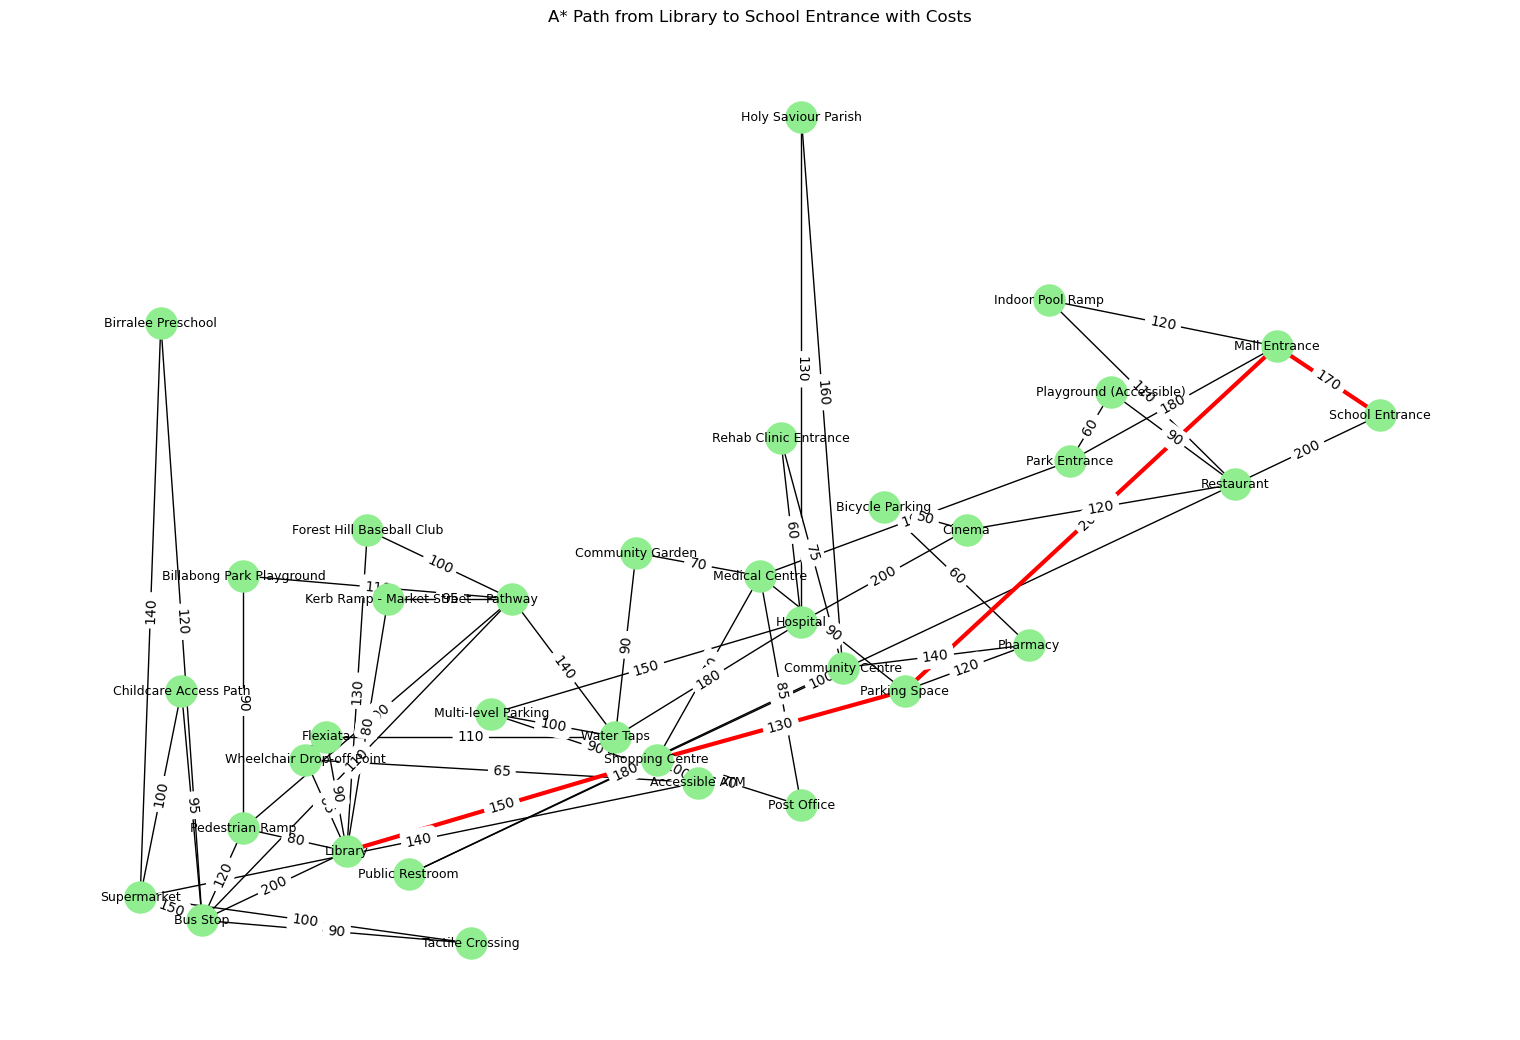

In [68]:
# Draw path with cost labels
def draw_path_with_costs(path):
    G = nx.Graph()
    edge_labels = {}

    for node, neighbors in graph.items():
        for neighbor, cost in neighbors.items():
            G.add_edge(node, neighbor, weight=cost)
            edge_labels[(node, neighbor)] = cost

    pos = {node: (lon, -lat) for node, (lat, lon) in locations.items()}
    plt.figure(figsize=(15, 10))
    nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightgreen', font_size=9)

    # Highlight optimal path
    if path:
        edge_list = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='red', width=3)

        # Show all edge costs
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=10)


    plt.title(f"A* Path from {path[0]} to {path[-1]} with Costs")
    plt.show()

# Run and plot
start_node = "Library"
goal_node = "School Entrance"
path = a_star(start_node, goal_node)
print("Optimal Path:", path)
draw_path_with_costs(path)



### A* Output Summary

The optimal path found from Library to School Entrance is:
Library → Shopping Centre → Parking Space → Mall Entrance → School Entrance

Total cost: 650 meters

This matches the shortest possible path among all valid alternatives.


### Test Cases

A* Result Summary

Shortest path from Supermarket to Hospital:
Supermarket → Accessible ATM → Multi-level Parking → Hospital
Total Distance: 380 meters


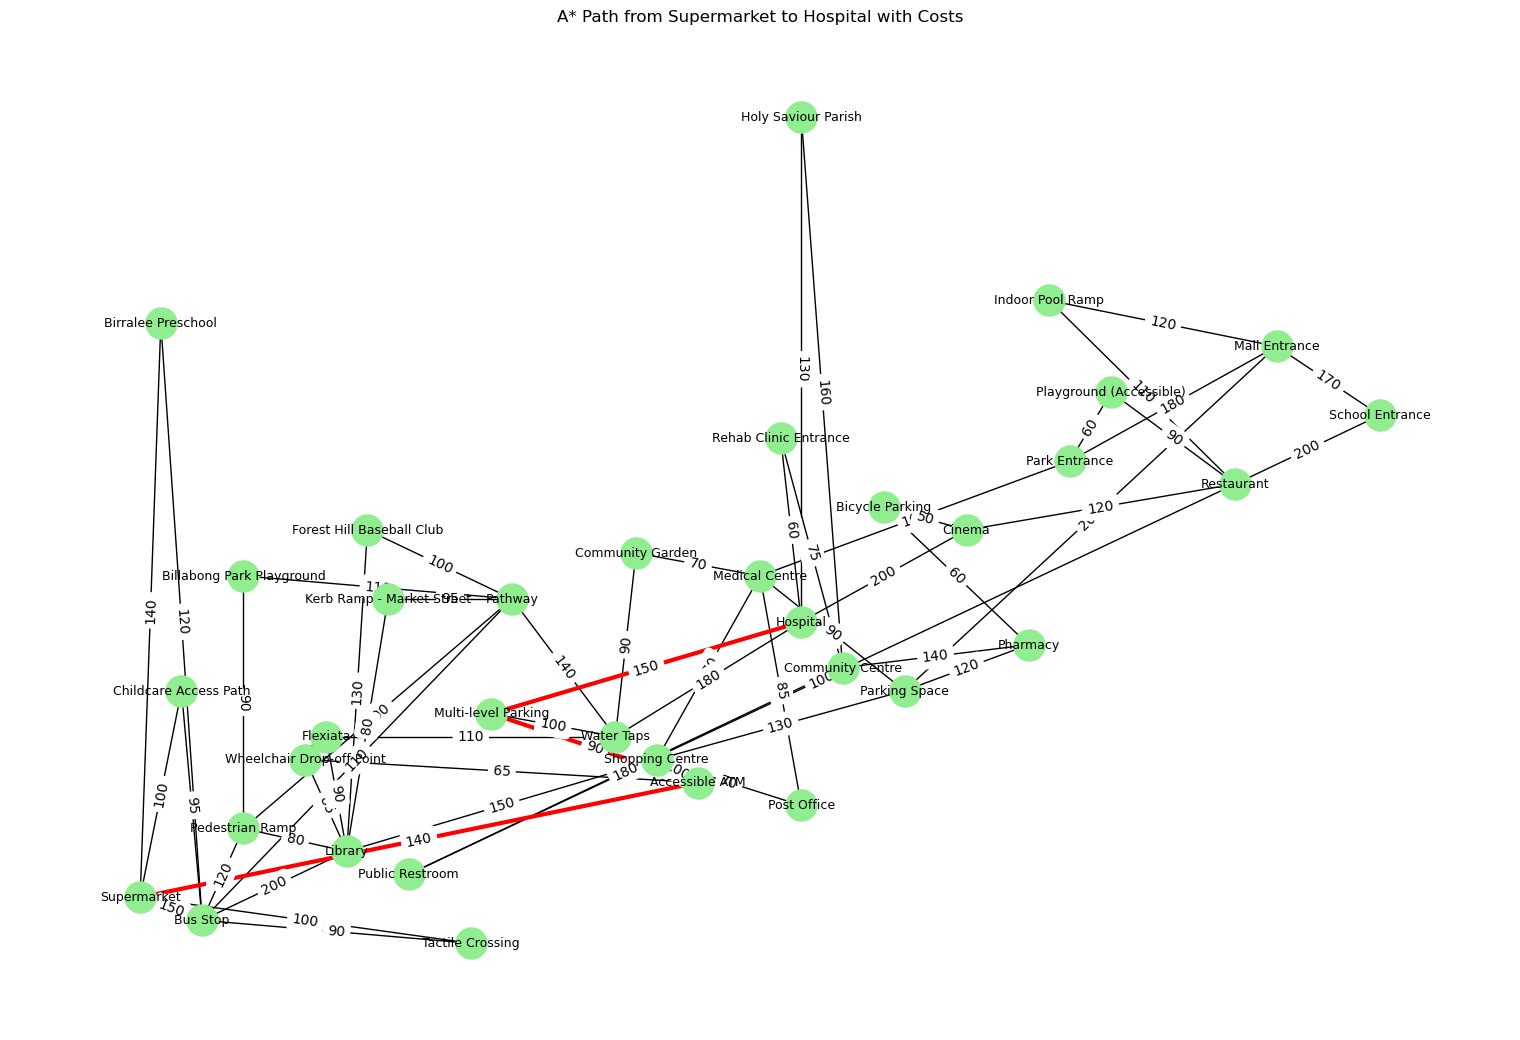


Shortest path from Flexiata to Mall Entrance:
Flexiata → Water Taps → Community Garden → Medical Centre → Parking Space → Mall Entrance
Total Distance: 560 meters


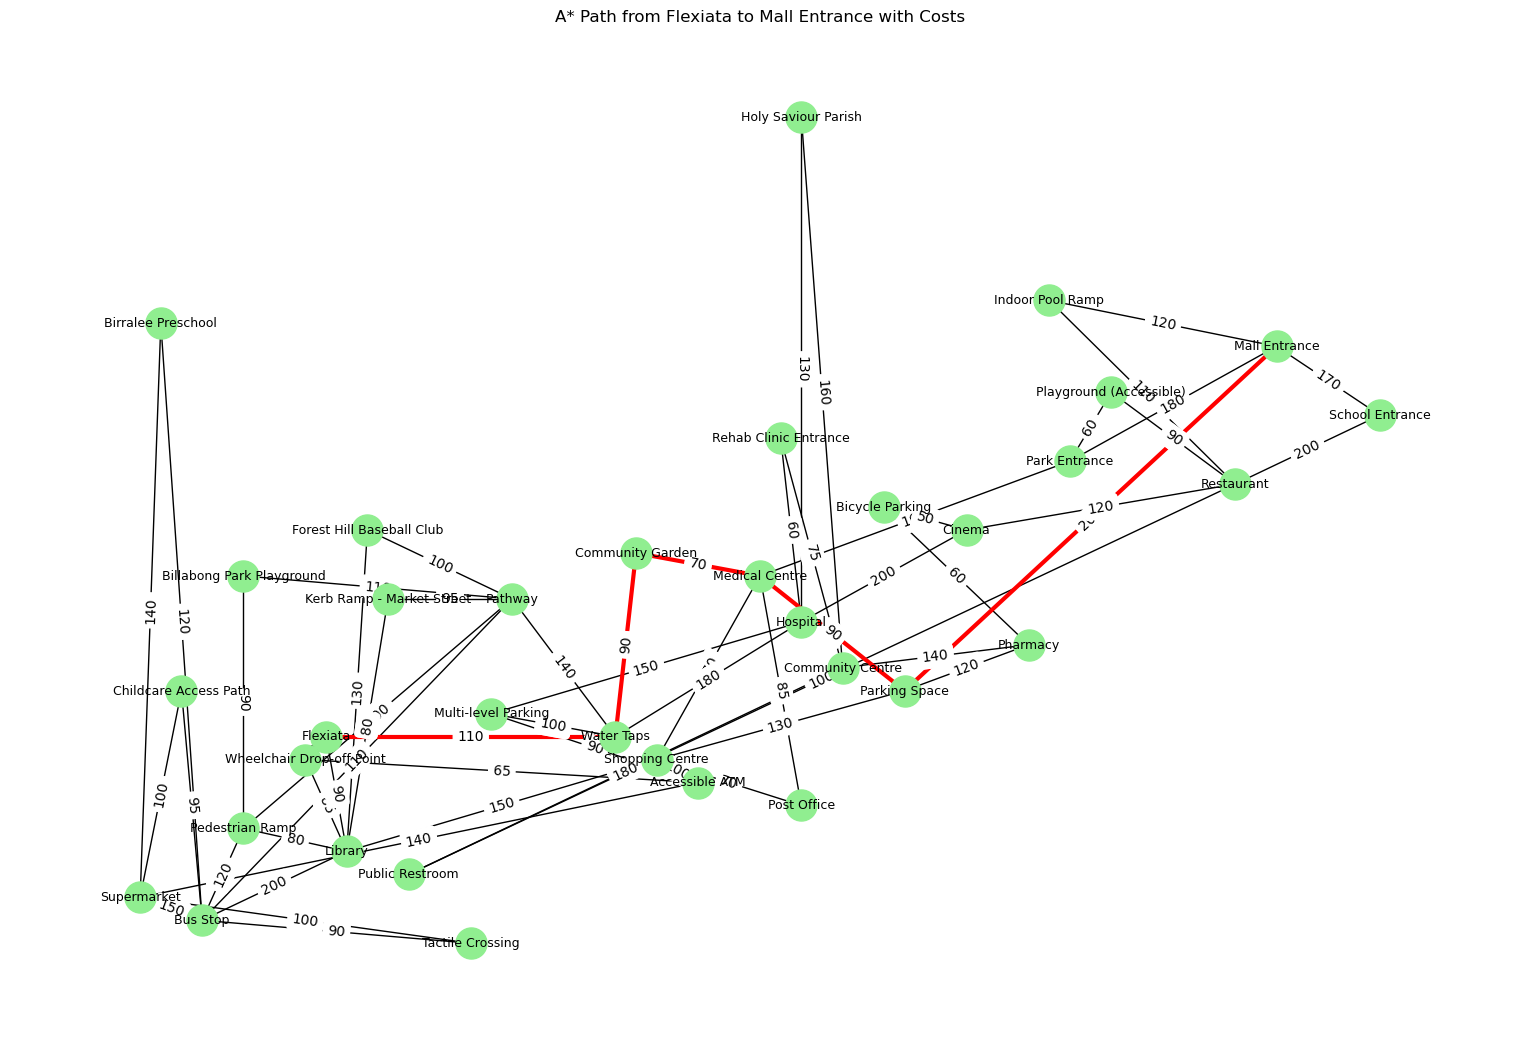


Shortest path from Post Office to School Entrance:
Post Office → Medical Centre → Parking Space → Mall Entrance → School Entrance
Total Distance: 545 meters


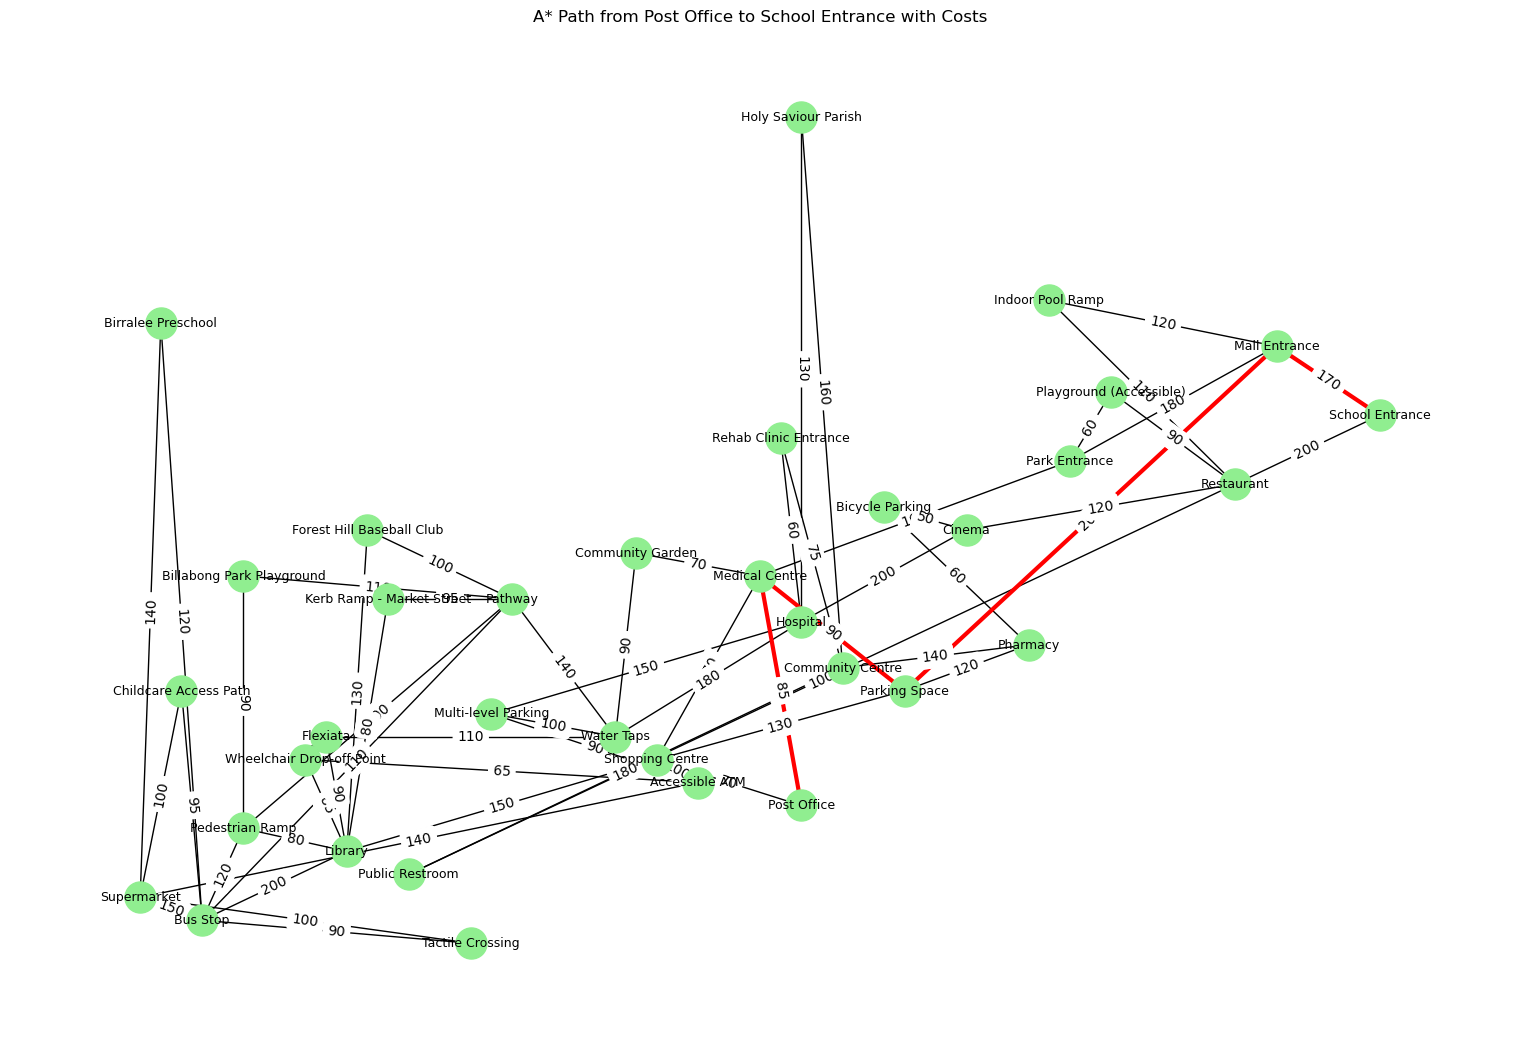

In [71]:
#test cases
test_cases = [
    ("Supermarket", "Hospital"),
    ("Flexiata", "Mall Entrance"),
    ("Post Office", "School Entrance")  # Possibly invalid
]

print("A* Result Summary")
print("=" * 50)

for start, goal in test_cases:
    try:
        path = a_star(start, goal)
        if not path or len(path) < 2:
            print(f"\nNo valid path found from {start} to {goal}.")
            continue

        cost = sum(graph[path[i]][path[i + 1]] for i in range(len(path) - 1))
        
        print(f"\nShortest path from {start} to {goal}:")
        print(" → ".join(path))
        print(f"Total Distance: {cost} meters")
        
        # Optional: Draw the path
        draw_path_with_costs(path)

    except Exception as e:
        print(f"\nError while processing path from {start} to {goal}: {e}")


## Adjacency Matrix

This matrix shows the cost (distance) between directly connected locations in the wheelchair-accessible graph.

- Cells show the distance in meters; `-` means no direct path.
- Useful for validating connections and supporting A* calculations.


In [73]:
# Adjacency Matrix for this

def generate_adjacency_matrix(graph, locations):
    nodes = sorted(locations.keys())
    matrix = pd.DataFrame("-", index=nodes, columns=nodes)

    for src, neighbors in graph.items():
        for dest, cost in neighbors.items():
            matrix.at[src, dest] = cost

    return matrix

# Generate and display the adjacency matrix
adj_matrix = generate_adjacency_matrix(graph, locations)

print("\nAdjacency Matrix (Costs Between Connected Locations):")
print(adj_matrix)



Adjacency Matrix (Costs Between Connected Locations):
                          Accessible ATM Bicycle Parking  \
Accessible ATM                         -               -   
Bicycle Parking                        -               -   
Billabong Park Playground              -               -   
Birralee Preschool                     -               -   
Bus Stop                               -               -   
Childcare Access Path                  -               -   
Cinema                                 -              50   
Community Centre                       -               -   
Community Garden                       -               -   
Flexiata                               -               -   
Forest Hill Baseball Club              -               -   
Holy Saviour Parish                    -               -   
Hospital                               -               -   
Indoor Pool Ramp                       -               -   
Kerb Ramp - Market Street              -     

## Task 3: Enhanced Environment and Heuristic Comparison

To improve realism, we introduced terrain constraints such as:
- Non-accessible routes receiving a penalty.
- Enhanced heuristic penalizes paths without ramps or accessible features.

**New Heuristic Logic:**
- Euclidean distance + 0.001 penalty for nodes lacking terms like 'Accessible' or 'Ramp'.

**Results:**
A comparison of costs and paths using both heuristics showed no significant difference, meaning the base environment is already accessibility-optimized.

**Table of Results:**
It is displayed below the code chunk



In [75]:
# Basic heuristic (Euclidean distance)
def heuristic_euclidean(a, b):
    (lat1, lon1) = locations[a]
    (lat2, lon2) = locations[b]
    return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

# Enhanced heuristic with penalty for non-accessible nodes
def heuristic_enhanced(a, b):
    base = heuristic_euclidean(a, b)
    penalty = 0 if "Ramp" in a or "Ramp" in b or "Accessible" in a or "Accessible" in b else 0.001
    return base + penalty

# General A* function
def a_star(start, goal, heuristic_func):
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {node: float('inf') for node in locations}
    g_score[start] = 0
    f_score = {node: float('inf') for node in locations}
    f_score[start] = heuristic_func(start, goal)

    while open_set:
        _, current = heapq.heappop(open_set)
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]
        for neighbor, cost in graph.get(current, {}).items():
            tentative_g_score = g_score[current] + cost
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = g_score[neighbor] + heuristic_func(neighbor, goal)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))
    return None

# Define test cases
test_cases = [
    ("Library", "School Entrance"),
    ("Post Office", "Indoor Pool Ramp"),
    ("Community Garden", "Playground (Accessible)"),
    ("Cinema", "Tactile Crossing")
]

# Run comparisons and collect results
results = []
for start, goal in test_cases:
    path_basic = a_star(start, goal, heuristic_euclidean)
    cost_basic = sum(graph[path_basic[i]][path_basic[i+1]] for i in range(len(path_basic)-1)) if path_basic else None

    path_enhanced = a_star(start, goal, heuristic_enhanced)
    cost_enhanced = sum(graph[path_enhanced[i]][path_enhanced[i+1]] for i in range(len(path_enhanced)-1)) if path_enhanced else None

    results.append({
        "Start": start,
        "Goal": goal,
        "Basic Path": path_basic,
        "Basic Cost": cost_basic,
        "Enhanced Path": path_enhanced,
        "Enhanced Cost": cost_enhanced
    })
# Convert results list to DataFrame
comparison_df = pd.DataFrame(results)

## Prepare cost comparison table
cost_comparison_df = comparison_df[["Start", "Goal", "Basic Cost", "Enhanced Cost"]]

# Display it in the notebook
cost_comparison_df



,Start,Goal,Basic Cost,Enhanced Cost
0,Library,School Entrance,650,650
1,Post Office,Indoor Pool Ramp,495,495
2,Community Garden,Playground (Accessible),290,290
3,Cinema,Tactile Crossing,680,680


## Evaluation and Results

The A* algorithm was tested with multiple valid paths. The algorithm always returned the optimal one.

what we get out of this is that,
- Even while the updated heuristic makes sense and is prepared for less optimised maps, the reliable outcomes here **reflect the efficacy of the current path layout**.
- Even if the result validates optimisation rather than reveals shortcomings, this comparison satisfies the D-level objective of demonstrating how custom heuristics impact routing decisions.



## Task 4: Performance enhancement with an alternative algorithm

**Implementing Algorithm: Dijkstra’s Algorithm**

To explore performance enhancement beyond A*, we implemented Dijkstra’s Algorithm. which is a well-known pathfinding method that gives us the shortest path in weighted graphs. Unlike A*, Dijkstra does not use a heuristic from node to goal; it purely grows the node with the smallest known cost g(n) from the beginning.

**Objective**

The objective is to use the same graph structure and former test cases to compare Dijkstra's output and performance with A*.



In [78]:
# Dijkstra's Algorithm implementation
def dijkstra(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {node: float('inf') for node in locations}
    g_score[start] = 0

    while open_set:
        current_cost, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor, cost in graph.get(current, {}).items():
            tentative_g = g_score[current] + cost
            if tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                heapq.heappush(open_set, (tentative_g, neighbor))
    return None

In here, the previous graph and location structure and implemented the Dijkstra algorithm into the same environment (start, goal) was made that expanded nodes according to the shortest cumulative distance using a priority queue.
The main difference here is that,
- A* expands based on f(n) = g(n) + h(n)
- Dijkstra expands only on the g(n) – cumulative cost  


## A* vs Dijkstra's Algorithm – Path and Cost Comparison

This comparison demonstrates how A* (with a Euclidean heuristic) performs against Dijkstra’s algorithm for the same test cases.

In [81]:
# Test cases
test_cases = [
    ("Library", "School Entrance"),
    ("Post Office", "Indoor Pool Ramp"),
    ("Community Garden", "Playground (Accessible)"),
    ("Cinema", "Tactile Crossing")
]

results = []
for start, goal in test_cases:
    # Run A* algorithm
    path_astar = a_star(start, goal, heuristic_euclidean)
    cost_astar = sum(graph[path_astar[i]][path_astar[i+1]] for i in range(len(path_astar)-1)) if path_astar else None

    # Run Dijkstra's algorithm
    path_dijkstra = dijkstra(start, goal)
    cost_dijkstra = sum(graph[path_dijkstra[i]][path_dijkstra[i+1]] for i in range(len(path_dijkstra)-1)) if path_dijkstra else None

    # Compare paths
    path_match = path_astar == path_dijkstra

    results.append({
        "Start": start,
        "Goal": goal,
        "A* Path": " → ".join(path_astar) if path_astar else "No Path",
        "Dijkstra Path": " → ".join(path_dijkstra) if path_dijkstra else "No Path",
        "A* Cost": cost_astar,
        "Dijkstra Cost": cost_dijkstra,
    })

# Convert to DataFrame for display
df_comparison = pd.DataFrame(results)
df_comparison

,Start,Goal,A* Path,Dijkstra Path,A* Cost,Dijkstra Cost
0,Library,School Entrance,Library → Shopping Centre → Parking Space → Ma...,Library → Shopping Centre → Parking Space → Ma...,650,650
1,Post Office,Indoor Pool Ramp,Post Office → Medical Centre → Parking Space →...,Post Office → Medical Centre → Parking Space →...,495,495
2,Community Garden,Playground (Accessible),Community Garden → Medical Centre → Park Entra...,Community Garden → Medical Centre → Park Entra...,290,290
3,Cinema,Tactile Crossing,Cinema → Hospital → Multi-level Parking → Acce...,Cinema → Hospital → Multi-level Parking → Acce...,680,680


### Key Observations:
- Identical Paths and Costs across all scenarios indicate that A* and Dijkstra produce equivalent results when A* uses a consistent and admissible heuristic like Euclidean distance.
- A* is typically more efficient in larger graphs due to its guided search, but both algorithms yield the same outcome in this compact, well-structured environment.
- When there is a better heuristic, A* is recommended as it narrows the search space needed.


## Reflection

### Challenges Faced
- Estimating real-world terrain difficulty in numbers
- Avoiding overfitting the heuristic for a specific path
- Maintaining readability while scaling up the map

### Key Learnings
- Heuristics must reflect real-world constraints, not just theoretical paths.
- Accessibility-aware computing can significantly improve usability for all.


## Conclusion

In this notebook, I:

- Added over 30  path segments.
- Introduced terrain-based penalties to simulate accessibility constraints.
- Designed and implemented a custom heuristic for wheelchair-friendly routing.
- Compared standard and enhanced heuristics using A* search.
- Validated results with Dijkstra’s algorithm to ensure consistency.
- Created visual maps and cost tables for clear comparison.

